<a href="https://colab.research.google.com/github/Chanthul4054/E-Policing-An-Integrated-Spatio-Temporal-Crime-Forecasting-and-Decision-Support-System/blob/Spatio-Temporal-Crime-Prediction-System/Component_1_DPP%26DC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Component based data preprocessing

"To generate a weekly probability score (0-1) for next week  for every GN Division, specific to a user-selected crime type, by analyzing historical trends, land use, and spatial lags."

Historical Analysis (Past Week): A diagnostic tool that shows exactly what happened, allowing users to compare the "Predicted" risk against "Actual" results.

##Preprocessing & Data Cleaning steps performed


Remove Irrelevant Columns

Handling Typos/Inconsistencies

Coordinate Validation

Datetime Conversion

Boolean Mapping

Categorical Encoding

Temporal Decomposition



#EDA

Temporal Validation (Validating your Datetime Conversions)

*   Plot a Crime Count Trend Line over time. This validates your "Datetime Conversion" and checks for seasonal spikes.
*   Use a Heatmap for Time of Day vs. Day of Week. This visually justifies why your model needs the "Hour" and "Day_of_Week" features you created during preprocessing.

Spatial Validation (Validating Coordinate & GN Division Cleaning)

*   Create a Geospatial Scatter Plot using latitude and longitude. If any points appear outside your expected region (e.g., in the ocean), it means your "Coordinate Validation" step needs further refinement.
*   Use a Bar Chart for Crime Density by GN Division. This highlights the "Natural Hotspots" in your historical data, which serves as a baseline for your "Crime Hotspot Prediction" task.

Categorical & Demographic Validation (Validating Encoding & Mapping)

*   Create Count Plots for Crime Types. Given that you have 1,608 rows, you need to see if there is a "Class Imbalance". For example, if "Burglary" is 80% of your data, your "Crime Type Classification" model will be biased.
*   Plot Victim Age Distribution (Histogram). This validates your "Handling Typos" step by ensuring no ages are impossible (e.g., 200 years old).







## Import libraries

In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.utils.class_weight import compute_class_weight
import json

import os
import joblib




In [ ]:
import sklearn, lightgbm, joblib, pandas, flask, pyarrow, numpy
print(f"flask=={flask.__version__}")
print(f"scikit-learn=={sklearn.__version__}")
print(f"lightgbm=={lightgbm.__version__}")
print(f"pandas=={pandas.__version__}")
print(f"joblib=={joblib.__version__}")
print(f"pyarrow=={pyarrow.__version__}")
print(f"numpy=={numpy.__version__}")

flask==3.1.2
scikit-learn==1.6.1
lightgbm==4.6.0
pandas==2.2.2
joblib==1.5.3
pyarrow==18.1.0
numpy==2.0.2


/tmp/ipython-input-1256146554.py:2: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in Flask 3.2. Use feature detection or 'importlib.metadata.version("flask")' instead.
  print(f"flask=={flask.__version__}")


##Component Based Preprocessing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
crime_df = pd.read_csv('/content/drive/MyDrive/DSGP/CrimeData_v3.csv')

In [ ]:
crime_df

,crime,location,date,sex,victim_ethnicity,victim_age,time,weather,latitude,longitude,holiday_name,is_holiday,land_use_type,gn_division,gn_pcode,gn_population,gn_distance_m,victim_ethnicity,status_report
0,burglary,mulgampola,2019-12-31,f,muslim,54,08:17:00,Cloudy,7.280544,80.616500,Non-Holiday,0,General Urban,Welata,LK2130170,21826,311.8,muslim,Valid
1,burglary,car park,2020-01-04,m,sinhala,42,02:00:00,Rainy,7.283445,80.619385,Non-Holiday,0,Commercial,Katukele West,LK2130105,8913,352.4,sinhala,Valid
2,theft,bus stand,2020-01-08,f,sinhala,20,21:01:00,Rainy,7.256425,80.590461,Eid al-Adha,1,Commercial,Penideniya,LK2139135,16411,518.6,sinhala,Valid
3,vehicle theft,aniwatte,2020-01-10,m,sinhala,29,12:10:00,Cloudy,7.290058,80.622438,Adhi Vap Full Moon Poya Day,1,General Urban,Aniwatta East,LK2130100,1107,381.5,sinhala,Valid
4,robbery,dutugamunu mawatha,2020-01-11,m,sinhala,59,02:39:00,Rainy,7.312344,80.645687,Non-Holiday,0,General Urban,Aruppala East,LK2130050,1293,322.6,sinhala,Valid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1603,drugs,walespark,2025-07-30,m,sinhala,65,09:19:00,Rainy,7.291772,80.636707,Non-Holiday,0,Commercial,Mahanuwara,LK2130120,11613,518.0,sinhala,Valid
1604,drugs,peradeniya road,2025-08-16,m,sinhala,59,04:38:00,Rainy,7.280930,80.619477,Non-Holiday,0,General Urban,Suduhumpala West,LK2130165,18808,353.7,sinhala,Valid
1605,robbery,provincial education department,2025-09-13,f,sinhala,50,07:25:00,Rainy,7.290341,80.633563,Non-Holiday,0,Commercial,Bogambara,LK2130145,2198,315.0,sinhala,Valid
1606,robbery,post office,2025-09-17,f,sinhala,61,20:12:00,Rainy,7.292186,80.633475,Non-Holiday,0,Commercial,Ihala Katukele,LK2130115,6925,335.7,sinhala,Valid


In [ ]:
crime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1608 entries, 0 to 1607
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   crime              1608 non-null   object 
 1   location           1608 non-null   object 
 2   date               1608 non-null   object 
 3   sex                1608 non-null   object 
 4   victim_ethnicity   1608 non-null   object 
 5   victim_age         1608 non-null   int64  
 6   time               1608 non-null   object 
 7   weather            1608 non-null   object 
 8   latitude           1608 non-null   float64
 9   longitude          1608 non-null   float64
 10  holiday_name       1608 non-null   object 
 11  is_holiday         1608 non-null   int64  
 12  land_use_type      1608 non-null   object 
 13  gn_division        1608 non-null   object 
 14  gn_pcode           1608 non-null   object 
 15  gn_population      1608 non-null   int64  
 16  gn_distance_m      1608 

In [ ]:
crime_df.describe()

,victim_age,latitude,longitude,is_holiday,gn_population,gn_distance_m
count,1608.000000,1608.000000,1608.000000,1608.000000,1608.000000,1608.000000
mean,42.602612,7.285506,80.633042,0.070896,8630.593284,398.776306
std,13.871646,0.025415,0.021201,0.256730,6767.678765,640.411182
min,15.000000,7.094806,80.528761,0.000000,926.000000,6.700000
25%,32.000000,7.279031,80.624353,0.000000,2198.000000,220.675000
50%,42.000000,7.289164,80.634393,0.000000,6925.000000,316.150000
75%,52.000000,7.294233,80.639486,0.000000,13050.000000,445.600000
max,78.000000,7.499662,80.764916,1.000000,22268.000000,8483.300000


### Handle data Inconsistenmcy

In [ ]:
crime_df['crime'] = crime_df['crime'].str.replace('vehicle theft', 'vehicle_theft')

###  Temporal Decomposition

####  Extracts temporal features from crime dates

Month (1-12)

Day of week (0-6)

Weekend flag (1 if Sat/Sun)

Year

In [ ]:
crime_df['date'] = pd.to_datetime(crime_df['date'])

# Extract the month
crime_df['month'] = crime_df['date'].dt.month

# Extract the day of the week
crime_df['day_of_week'] = crime_df['date'].dt.dayofweek

# Create 'is_weekend
crime_df['is_weekend'] = crime_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Extract the year
crime_df['year'] = crime_df['date'].dt.year

In [ ]:
crime_df

,crime,location,date,sex,victim_ethnicity,victim_age,time,weather,latitude,longitude,...,gn_division,gn_pcode,gn_population,gn_distance_m,victim_ethnicity,status_report,month,day_of_week,is_weekend,year
0,burglary,mulgampola,2019-12-31,f,muslim,54,08:17:00,Cloudy,7.280544,80.616500,...,Welata,LK2130170,21826,311.8,muslim,Valid,12,1,0,2019
1,burglary,car park,2020-01-04,m,sinhala,42,02:00:00,Rainy,7.283445,80.619385,...,Katukele West,LK2130105,8913,352.4,sinhala,Valid,1,5,1,2020
2,theft,bus stand,2020-01-08,f,sinhala,20,21:01:00,Rainy,7.256425,80.590461,...,Penideniya,LK2139135,16411,518.6,sinhala,Valid,1,2,0,2020
3,vehicle_theft,aniwatte,2020-01-10,m,sinhala,29,12:10:00,Cloudy,7.290058,80.622438,...,Aniwatta East,LK2130100,1107,381.5,sinhala,Valid,1,4,0,2020
4,robbery,dutugamunu mawatha,2020-01-11,m,sinhala,59,02:39:00,Rainy,7.312344,80.645687,...,Aruppala East,LK2130050,1293,322.6,sinhala,Valid,1,5,1,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1603,drugs,walespark,2025-07-30,m,sinhala,65,09:19:00,Rainy,7.291772,80.636707,...,Mahanuwara,LK2130120,11613,518.0,sinhala,Valid,7,2,0,2025
1604,drugs,peradeniya road,2025-08-16,m,sinhala,59,04:38:00,Rainy,7.280930,80.619477,...,Suduhumpala West,LK2130165,18808,353.7,sinhala,Valid,8,5,1,2025
1605,robbery,provincial education department,2025-09-13,f,sinhala,50,07:25:00,Rainy,7.290341,80.633563,...,Bogambara,LK2130145,2198,315.0,sinhala,Valid,9,5,1,2025
1606,robbery,post office,2025-09-17,f,sinhala,61,20:12:00,Rainy,7.292186,80.633475,...,Ihala Katukele,LK2130115,6925,335.7,sinhala,Valid,9,2,0,2025


### Crime Type Distribution

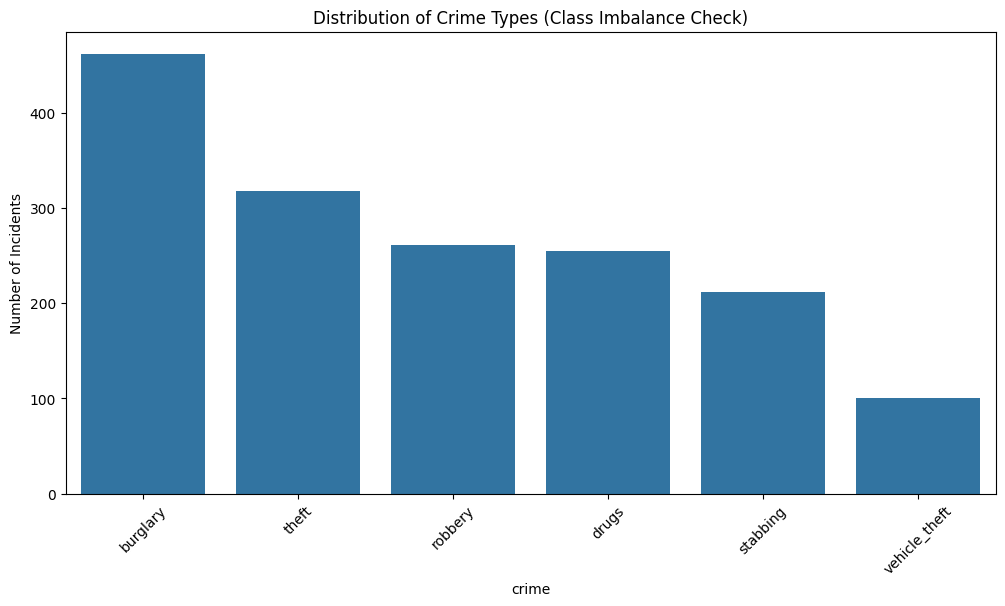

crime
burglary         462
theft            318
robbery          261
drugs            255
stabbing         212
vehicle_theft    100
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=crime_df, x='crime', order=crime_df['crime'].value_counts().index)
plt.title('Distribution of Crime Types (Class Imbalance Check)')
plt.xticks(rotation=45)
plt.ylabel('Number of Incidents')
plt.show()

# Print exact counts for your report
print(crime_df['crime'].value_counts())

### Time-Binning



#### Devide the 24-hour day in to blocks[(Night)(Morning)(Afternoon)(Evening)]




In [ ]:
#Create time bins-> devide the 24-hour day in to blocks

#Extract hour and create bins
crime_df['hour'] = pd.to_datetime(crime_df['time']).dt.hour

# Define bins 0-6 (Night), 6-12 (Morning), 12-18 (Afternoon), 18-24 (Evening)
bins = [0, 6, 12, 18, 24]
labels = ['night', 'morning', 'afternoon', 'evening']
crime_df['time_bin'] = pd.cut(crime_df['hour'], bins=bins, labels=labels, right=False)
crime_df['time_bin'] = pd.Categorical(crime_df['time_bin'], categories=labels, ordered=True)

/tmp/ipython-input-1272401930.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crime_df['hour'] = pd.to_datetime(crime_df['time']).dt.hour


#### Geospatial Incident Validation

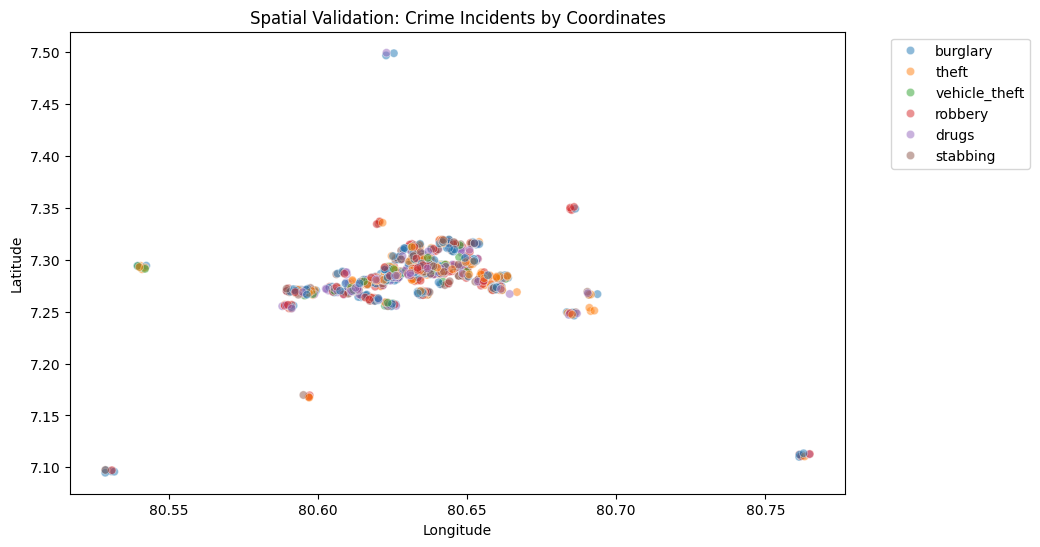

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=crime_df, x='longitude', y='latitude', hue='crime', alpha=0.5)
plt.title('Spatial Validation: Crime Incidents by Coordinates')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
# Fixed the 'loc' error here: changed '2' to 'upper left'
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
crime_df


,crime,location,date,sex,victim_ethnicity,victim_age,time,weather,latitude,longitude,...,gn_population,gn_distance_m,victim_ethnicity,status_report,month,day_of_week,is_weekend,year,hour,time_bin
0,burglary,mulgampola,2019-12-31,f,muslim,54,08:17:00,Cloudy,7.280544,80.616500,...,21826,311.8,muslim,Valid,12,1,0,2019,8,morning
1,burglary,car park,2020-01-04,m,sinhala,42,02:00:00,Rainy,7.283445,80.619385,...,8913,352.4,sinhala,Valid,1,5,1,2020,2,night
2,theft,bus stand,2020-01-08,f,sinhala,20,21:01:00,Rainy,7.256425,80.590461,...,16411,518.6,sinhala,Valid,1,2,0,2020,21,evening
3,vehicle_theft,aniwatte,2020-01-10,m,sinhala,29,12:10:00,Cloudy,7.290058,80.622438,...,1107,381.5,sinhala,Valid,1,4,0,2020,12,afternoon
4,robbery,dutugamunu mawatha,2020-01-11,m,sinhala,59,02:39:00,Rainy,7.312344,80.645687,...,1293,322.6,sinhala,Valid,1,5,1,2020,2,night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1603,drugs,walespark,2025-07-30,m,sinhala,65,09:19:00,Rainy,7.291772,80.636707,...,11613,518.0,sinhala,Valid,7,2,0,2025,9,morning
1604,drugs,peradeniya road,2025-08-16,m,sinhala,59,04:38:00,Rainy,7.280930,80.619477,...,18808,353.7,sinhala,Valid,8,5,1,2025,4,night
1605,robbery,provincial education department,2025-09-13,f,sinhala,50,07:25:00,Rainy,7.290341,80.633563,...,2198,315.0,sinhala,Valid,9,5,1,2025,7,morning
1606,robbery,post office,2025-09-17,f,sinhala,61,20:12:00,Rainy,7.292186,80.633475,...,6925,335.7,sinhala,Valid,9,2,0,2025,20,evening


### Spatial Feature Aggregation

Converts daily crime data to weekly summaries per GN division

* Groups by week + GN division
* Counts total crimes per week per division

In [ ]:
#The primary key -> gn_pcode
# Convert date to a weekly period
crime_df['week_start'] = pd.to_datetime(crime_df['date']).dt.to_period('W').dt.start_time

# Group by Date and GN Division
weekly_aggregated = crime_df.groupby([
    'week_start', 'gn_pcode', 'gn_division', 'gn_population',
    'land_use_type'
], observed=True).size().reset_index(name='total_crimes')

# Sort by date and division for a clear timeline
weekly_aggregated = weekly_aggregated.sort_values(by=['week_start', 'gn_division'])



In [ ]:
weekly_aggregated

,week_start,gn_pcode,gn_division,gn_population,land_use_type,total_crimes
0,2019-12-30,LK2130105,Katukele West,8913,Commercial,1
1,2019-12-30,LK2130170,Welata,21826,General Urban,1
3,2020-01-06,LK2130100,Aniwatta East,1107,General Urban,1
2,2020-01-06,LK2130050,Aruppala East,1293,General Urban,1
5,2020-01-06,LK2139135,Penideniya,16411,Commercial,1
...,...,...,...,...,...,...
1440,2025-07-28,LK2130120,Mahanuwara,11613,Commercial,1
1441,2025-08-11,LK2130165,Suduhumpala West,18808,General Urban,1
1442,2025-09-08,LK2130145,Bogambara,2198,Commercial,1
1443,2025-09-15,LK2130115,Ihala Katukele,6925,Commercial,1


### Spatio Temporal Grid Sampling + Target Generation

What it does:

* Creates complete grid: Every week × Every GN division (no missing combinations)
* Pivots crime types into columns (burglary, theft, robbery, etc.)
* Pivots time bins into columns (night, morning, afternoon, evening)
* Creates targets using shift(-1) → Labels "did crime happen NEXT week?"

In [ ]:

all_weeks = weekly_aggregated['week_start'].unique()
all_gn_codes = weekly_aggregated['gn_pcode'].unique()
all_gn = (weekly_aggregated
    .groupby('gn_pcode', as_index=False)
    .agg({
        'gn_division': 'first',
        'gn_population': 'first',
        'land_use_type': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
    }))

index = pd.MultiIndex.from_product(
    [all_weeks, all_gn_codes],
    names=['week_start', 'gn_pcode']
)
master_grid = pd.DataFrame(index=index).reset_index()

crime_pivot = crime_df.pivot_table(
    index=['week_start', 'gn_pcode'],
    columns='crime',
    aggfunc='size',
    fill_value=0
).reset_index()

time_pivot = crime_df.pivot_table(
    index=['week_start', 'gn_pcode'],
    columns='time_bin',
    aggfunc='size',
    fill_value=0
).reset_index()

final_grid = pd.merge(master_grid, all_gn, on='gn_pcode', how='left')
final_grid = pd.merge(final_grid, weekly_aggregated[['week_start', 'gn_pcode', 'total_crimes']], on=['week_start', 'gn_pcode'], how='left')
final_grid = pd.merge(final_grid, crime_pivot, on=['week_start', 'gn_pcode'], how='left')
final_grid = pd.merge(final_grid, time_pivot, on=['week_start', 'gn_pcode'], how='left')
final_grid = final_grid.fillna(0)
final_grid = final_grid.sort_values(['gn_pcode', 'week_start'])

# Create targets
unique_crimes = crime_df['crime'].unique().tolist()

for crime in unique_crimes:
    target_col_name = f'target_{crime.lower().replace(" ", "_")}_next_week'
    final_grid[target_col_name] = final_grid.groupby('gn_pcode')[crime].shift(-1)
    final_grid[target_col_name] = (final_grid[target_col_name] > 0).astype(int)

final_grid['target_next_week_total'] = final_grid.groupby('gn_pcode')['total_crimes'].shift(-1)
final_grid['target_next_week_total'] = (final_grid['target_next_week_total'] > 0).astype(int)

final_grid = final_grid.dropna(subset=[f'target_{c.lower().replace(" ", "_")}_next_week' for c in unique_crimes])




/tmp/ipython-input-100080310.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  time_pivot = crime_df.pivot_table(


In [ ]:
final_grid


,week_start,gn_pcode,gn_division,gn_population,land_use_type,total_crimes,burglary,drugs,robbery,stabbing,...,morning,afternoon,evening,target_burglary_next_week,target_theft_next_week,target_vehicle_theft_next_week,target_robbery_next_week,target_drugs_next_week,target_stabbing_next_week,target_next_week_total
48,2019-12-30,LK2106015,Dehiwatta,3133,General Urban,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
120,2020-01-06,LK2106015,Dehiwatta,3133,General Urban,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
192,2020-01-13,LK2106015,Dehiwatta,3133,General Urban,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
264,2020-01-20,LK2106015,Dehiwatta,3133,General Urban,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
337,2020-01-27,LK2106015,Dehiwatta,3133,General Urban,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19652,2025-07-28,LK2154140,Pitakanda,16712,General Urban,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
19724,2025-08-11,LK2154140,Pitakanda,16712,General Urban,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
19796,2025-09-08,LK2154140,Pitakanda,16712,General Urban,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
19868,2025-09-15,LK2154140,Pitakanda,16712,General Urban,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


### Trend and Seasonality Extraction




- Labels month with the corresponding Sri Lankan monsoon season.
- Flag to show if a specific week contains a public holiday.
- Counts the number of weeks since the very first record
- Calculate the average number of each crime type over the previous four weeks
- Calculate the average of all crimes combined over the previous month

In [ ]:
#Extract Basic Time Components
final_grid['month'] = final_grid['week_start'].dt.month

# Map the Season -> weather patterns
def get_season(month):
    if month in [12, 1, 2]: return 'NE_monsoon'
    if month in [3, 4]: return 'first_inter'
    if month in [5, 6, 7, 8, 9]: return 'SW_monsoon'
    return 'second_inter'


### Feature Engineering

* Creates season dummy variables (one-hot encoding)
* Adds holiday flag (1 if week contains holiday)
* Adds time trend (weeks from start of dataset)
* Creates 4-week rolling averages for each crime type (shifted by 1 week to avoid leakage)
* Creates 4-week rolling average for total crimes (shifted)

In [ ]:

final_grid['season'] = final_grid['month'].apply(get_season)
final_grid = pd.get_dummies(final_grid, columns=['season'], prefix='season')

# Weekly Holiday Flag
crime_df['week_start'] = pd.to_datetime(crime_df['date']).dt.to_period('W').dt.start_time
weeks_with_holidays = crime_df[crime_df['is_holiday'] == 1]['week_start'].unique()
final_grid['has_holiday_in_week'] = final_grid['week_start'].isin(weeks_with_holidays).astype(int)

# Long-term Trend Indicator (Weeks from Start)
start_week = final_grid['week_start'].min()
final_grid['weeks_from_start'] = ((final_grid['week_start'] - start_week).dt.days // 7).astype(int)

#Automatically detect all crime types from the data
unique_crimes = crime_df['crime'].unique().tolist()

# Calculate Shifted 4-week Rolling Averages for EACH crime
# This tells the model if 'Theft' or 'Assault' has been increasing lately
for crime in unique_crimes:
    col_name = f'{crime.lower().replace(" ", "_")}_trend_4w'
    final_grid[col_name] = final_grid.groupby('gn_pcode')[crime].transform(
        lambda x: x.rolling(window=4, min_periods=1).mean()
    ).shift(1).fillna(0)

# Calculate shifted 4-week rolling average of total crimes
# This gives the model a sense of overall "neighborhood activity"
final_grid['total_crime_trend_4w'] = final_grid.groupby('gn_pcode')['total_crimes'].transform(
    lambda x: x.rolling(window=4, min_periods=4).mean()
).shift(1).fillna(0)




In [ ]:
final_grid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19953 entries, 48 to 19940
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   week_start                      19953 non-null  datetime64[ns]
 1   gn_pcode                        19953 non-null  object        
 2   gn_division                     19953 non-null  object        
 3   gn_population                   19953 non-null  int64         
 4   land_use_type                   19953 non-null  object        
 5   total_crimes                    19953 non-null  float64       
 6   burglary                        19953 non-null  float64       
 7   drugs                           19953 non-null  float64       
 8   robbery                         19953 non-null  float64       
 9   stabbing                        19953 non-null  float64       
 10  theft                           19953 non-null  float64       
 11  vehicl

### Spatio-Temporal Engineering

* Creates 1-week and 2-week lags for each crime (burglary last week, 2 weeks ago)
* Creates spatial lag → Average crimes in surrounding district, shifted by 1 week
* CRITICAL: Drops current week crime columns → Prevents future data leakage
* Shifts time bin features → Uses LAST week's time patterns, not this week's

In [ ]:
# Sort to ensure time is linear for each GN and Crime Type
final_grid = final_grid.sort_values(by=['gn_pcode', 'week_start'])

# DYNAMICALLY identify all specific crime types
unique_crimes = crime_df['crime'].unique().tolist()

# Temporal Lags for EACH specific crime
for crime in unique_crimes:
    crime_key = crime.lower().replace(" ", "_")
    # 1-week and 2-week history for the specific crime
    final_grid[f'{crime_key}_lag_1w'] = final_grid.groupby('gn_pcode')[crime].shift(1).fillna(0)
    final_grid[f'{crime_key}_lag_2w'] = final_grid.groupby('gn_pcode')[crime].shift(2).fillna(0)

# Correctly handle the trend lag (already shifted in the previous step, just ensure name matches)
# If you used 'total_crime_trend_4w' in the previous step, we use it here
final_grid['lag_total_1w'] = final_grid.groupby('gn_pcode')['total_crimes'].shift(1).fillna(0)
final_grid['lag_total_2w'] = final_grid.groupby('gn_pcode')['total_crimes'].shift(2).fillna(0)

# District Proxy logic (Spatial Lag)
final_grid['district_id'] = final_grid['gn_pcode'].astype(str).str[:4]


# We calculate the district average of total crimes to give context of the surrounding area
dist_avg = final_grid.groupby(['week_start','district_id'],as_index=False)['total_crimes'].mean()
dist_avg.rename(columns={'total_crimes': 'district_avg_crimes'}, inplace=True)
final_grid = pd.merge(final_grid, dist_avg, on=['week_start', 'district_id'], how='left')

final_grid['spatial_lag_1w'] = final_grid.groupby('gn_pcode')['district_avg_crimes'].shift(1).fillna(0)

final_grid = final_grid.drop(columns=['district_avg_crimes', 'district_id'])

print("\n🔧 Removing current week crime counts (we use lagged versions)...")

for crime in unique_crimes:
    if crime in final_grid.columns:
        final_grid = final_grid.drop(columns=[crime])
        print(f"   ✅ Dropped {crime} (using lag features instead)")

# Also drop current week total (we use lag_total_1w)
if 'total_crimes' in final_grid.columns:
    final_grid = final_grid.drop(columns=['total_crimes'])
    print(f"   ✅ Dropped total_crimes (using lag_total_1w instead)")

print("✅ Current week features removed!")


print("\n🔧 Shifting time bin features...")

for time_bin in ['night', 'morning', 'afternoon', 'evening']:
    if time_bin in final_grid.columns:
        final_grid[f'{time_bin}_lag_1w'] = final_grid.groupby('gn_pcode')[time_bin].shift(1).fillna(0)
        final_grid = final_grid.drop(columns=[time_bin])
        print(f"   ✅ Shifted {time_bin} → {time_bin}_lag_1w")

print("✅ Time bin features fixed!")




🔧 Removing current week crime counts (we use lagged versions)...
   ✅ Dropped burglary (using lag features instead)
   ✅ Dropped theft (using lag features instead)
   ✅ Dropped vehicle_theft (using lag features instead)
   ✅ Dropped robbery (using lag features instead)
   ✅ Dropped drugs (using lag features instead)
   ✅ Dropped stabbing (using lag features instead)
   ✅ Dropped total_crimes (using lag_total_1w instead)
✅ Current week features removed!

🔧 Shifting time bin features...
   ✅ Shifted night → night_lag_1w
   ✅ Shifted morning → morning_lag_1w
   ✅ Shifted afternoon → afternoon_lag_1w
   ✅ Shifted evening → evening_lag_1w
✅ Time bin features fixed!


### Class Imbalance Analysis

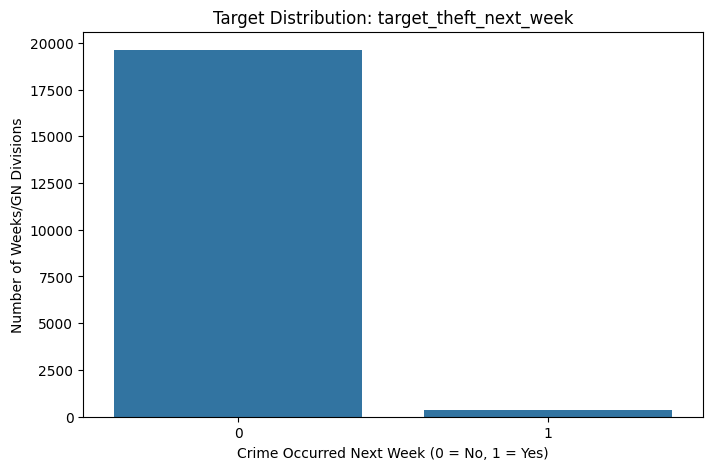

target_theft_next_week
0    98.285972
1     1.714028
Name: proportion, dtype: float64


In [ ]:
# Select one of your target columns to check imbalance (e.g., burglary)
target_to_check = 'target_theft_next_week'

plt.figure(figsize=(8, 5))
sns.countplot(x=target_to_check, data=final_grid)
plt.title(f'Target Distribution: {target_to_check}')
plt.xlabel('Crime Occurred Next Week (0 = No, 1 = Yes)')
plt.ylabel('Number of Weeks/GN Divisions')
plt.show()

# Calculate the exact percentage to justify class weights
print(final_grid[target_to_check].value_counts(normalize=True) * 100)

### Feature Exclusion


In [ ]:
final_grid = final_grid.drop(columns=['gn_division'])

In [ ]:
final_grid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19953 entries, 0 to 19952
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   week_start                      19953 non-null  datetime64[ns]
 1   gn_pcode                        19953 non-null  object        
 2   gn_population                   19953 non-null  int64         
 3   land_use_type                   19953 non-null  object        
 4   target_burglary_next_week       19953 non-null  int64         
 5   target_theft_next_week          19953 non-null  int64         
 6   target_vehicle_theft_next_week  19953 non-null  int64         
 7   target_robbery_next_week        19953 non-null  int64         
 8   target_drugs_next_week          19953 non-null  int64         
 9   target_stabbing_next_week       19953 non-null  int64         
 10  target_next_week_total          19953 non-null  int64         
 11  mo

### Encoding Categorical Variables

* One-hot encodes land use type (Residential, Commercial, General Urban)
* Label encodes GN code (GN_001 → 0, GN_002 → 1, etc.)
* Converts boolean columns to int
* Drops original string columns

In [ ]:
# One-Hot Encode Land Use
existing_categorical = [c for c in ['land_use_type'] if c in final_grid.columns]
final_grid = pd.get_dummies(final_grid, columns=existing_categorical)

# Label Encode the GN Code
le = LabelEncoder()
final_grid['gn_encoded'] = le.fit_transform(final_grid['gn_pcode'])

# Clean up Boolean columns
bool_cols = final_grid.select_dtypes(include=['bool']).columns
final_grid[bool_cols] = final_grid[bool_cols].astype(int)

cols_to_drop = ['gn_pcode', 'gn_division']
# Only drop if they exist in the dataframe to avoid errors
final_grid = final_grid.drop(columns=[c for c in cols_to_drop if c in final_grid.columns])

In [ ]:
final_grid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19953 entries, 0 to 19952
Data columns (total 46 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   week_start                      19953 non-null  datetime64[ns]
 1   gn_population                   19953 non-null  int64         
 2   target_burglary_next_week       19953 non-null  int64         
 3   target_theft_next_week          19953 non-null  int64         
 4   target_vehicle_theft_next_week  19953 non-null  int64         
 5   target_robbery_next_week        19953 non-null  int64         
 6   target_drugs_next_week          19953 non-null  int64         
 7   target_stabbing_next_week       19953 non-null  int64         
 8   target_next_week_total          19953 non-null  int64         
 9   month                           19953 non-null  int32         
 10  season_NE_monsoon               19953 non-null  int64         
 11  se


### NaN Scrubbing

* Removing rows with missing/invalid values
* Replaces "infinite" numbers with zeros


In [ ]:
# Dynamically build the list of all lag columns to scrub
# This includes the general lags AND the specific crime lags we created earlier
unique_crimes = crime_df['crime'].unique().tolist()
specific_lag_cols = [f'{c.lower().replace(" ", "_")}_lag_{i}w' for c in unique_crimes for i in [1, 2]]
general_lag_cols = ['lag_total_1w', 'lag_total_2w', 'spatial_lag_1w', 'total_crime_trend_4w']

# Combine all feature columns that must not be NaN
scrub_features = specific_lag_cols + general_lag_cols

# Add the Target columns to the scrub list
# We must drop the last week of data for each GN because we don't know the "future" yet
target_cols = [f'target_{c.lower().replace(" ", "_")}_next_week' for c in unique_crimes]
all_scrub_cols = scrub_features  + target_cols
print(f"Rows before scrubbing: {len(final_grid)}")

# Drop NaNs
# The model cannot process 'None' in features or targets during training
final_grid = final_grid.dropna(subset=all_scrub_cols)
final_grid = final_grid.replace([np.inf, -np.inf], 0)
print(f"Rows after scrubbing: {len(final_grid)}")
rows_before = len(final_grid)
final_grid = final_grid.dropna(subset=all_scrub_cols)
rows_after = len(final_grid)
print(f"Rows dropped: {rows_before - rows_after}")

Rows before scrubbing: 19953
Rows after scrubbing: 19953
Rows dropped: 0


In [ ]:
final_grid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19953 entries, 0 to 19952
Data columns (total 46 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   week_start                      19953 non-null  datetime64[ns]
 1   gn_population                   19953 non-null  int64         
 2   target_burglary_next_week       19953 non-null  int64         
 3   target_theft_next_week          19953 non-null  int64         
 4   target_vehicle_theft_next_week  19953 non-null  int64         
 5   target_robbery_next_week        19953 non-null  int64         
 6   target_drugs_next_week          19953 non-null  int64         
 7   target_stabbing_next_week       19953 non-null  int64         
 8   target_next_week_total          19953 non-null  int64         
 9   month                           19953 non-null  int32         
 10  season_NE_monsoon               19953 non-null  int64         
 11  se

#### Independent and Dependent variable

**Dependent variable**

    target_burglary_next_week
    target_theft_next_week
    target_vehicle_theft_next_week
    target_robbery_next_week
    target_drugs_next_week
    target_stabbing_next_week
    target_next_week_total (The aggregate outcome)

**Independent variable**

    The rest

#Temporal Train-Test Split


* Separates inference data → Latest week per GN (72 divisions for next week prediction)
* Creates train/val/test → 70/15/15 split from remaining data
* Time-based split → Train on earlier weeks, test on later weeks
* Validates all crime types have positive examples

- Train - model uses to learn
- Test - to measure of how accurately the model predicts crime
- Validation - tune the model's settings
- Inference - current-week data used to generate actual predictions for the upcoming week (When you run your Flask API, it uses the model (predict risk for the next week using this inference_df)

In [ ]:
# Define features (exclude metadata and targets)
exclude = ['gn_division', 'week_start', 'gn_pcode', 'total_crimes'] + \
          [col for col in final_grid.columns if 'target_' in col]

features = [col for col in final_grid.columns if col not in exclude]


print("="*70)
print("CREATING TRAIN/VALIDATION/TEST SPLIT")
print("="*70)

#IDENTIFY INFERENCE DATA

latest_week = final_grid['week_start'].max()
all_gn_divisions = final_grid['gn_encoded'].unique()

print(f"Total GN divisions: {len(all_gn_divisions)}")
print(f"Latest week: {latest_week}")

# Get each GN's most recent data
inference_rows = []
for gn in all_gn_divisions:
    gn_data = final_grid[final_grid['gn_encoded'] == gn].sort_values('week_start')
    if not gn_data.empty:
        latest_row = gn_data.iloc[-1].copy()
        # Add this check to see what the value is right now
        # print(f"DEBUG: GN {gn} has gn_encoded value: {latest_row['gn_encoded']}")
        inference_rows.append(latest_row)

inference_df = pd.DataFrame(inference_rows)

# CHECK THE OUTPUT HERE
print("\n--- FIRST 5 ROWS OF INFERENCE DF ---")
print(inference_df[['gn_encoded']].head())

unique_count = inference_df['gn_encoded'].nunique()
print(f"✅ Final Inference Data Check: {len(inference_df)} rows for {unique_count} unique GN Divisions.")

if len(inference_df) != 72:
    print("⚠️ WARNING: You do not have 72 divisions. Check your data source!")

print(f"\nInference columns: {inference_df.columns.tolist()}")
assert 'gn_encoded' in inference_df.columns, "Missing gn_encoded!"



# Get all data EXCEPT the latest week
train_test_pool = final_grid[final_grid['week_start'] < latest_week].copy()
target_cols = [col for col in train_test_pool.columns if 'target_' in col and '_next_week' in col]
train_test_pool = train_test_pool.dropna(subset=target_cols, how='all')


print(f"\n📈 Target distributions across ALL crime types:")
for target_col in sorted(target_cols):
    crime_name = target_col.replace('target_', '').replace('_next_week', '')
    pos_count = train_test_pool[target_col].sum()
    total = len(train_test_pool)
    pos_rate = (pos_count / total) * 100
    print(f"   {crime_name.upper():15s}: {int(pos_count):4d} positive ({pos_rate:5.2f}%)")


# TIME-BASED SPLIT (RECOMMENDED FOR TIME-SERIES) ---
train_test_pool = train_test_pool.sort_values('week_start')

# Calculate split points
n_total = len(train_test_pool)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)
# Remaining 15% for test

train_df = train_test_pool.iloc[:n_train]
val_df = train_test_pool.iloc[n_train:n_train+n_val]
test_df = train_test_pool.iloc[n_train+n_val:]


# VALIDATION CHECKS
print("\n" + "="*70)
print("VALIDATION CHECKS FOR ALL CRIME TYPES")
print("="*70)

all_valid = True
validation_results = {}

for target_col in sorted(target_cols):
    crime_name = target_col.replace('target_', '').replace('_next_week', '')

    train_pos = train_df[target_col].sum()
    val_pos = val_df[target_col].sum()
    test_pos = test_df[target_col].sum()

    validation_results[crime_name] = {
        'train': train_pos,
        'val': val_pos,
        'test': test_pos
    }

    # Check for critical issues
    if train_pos == 0:
        print(f"{crime_name.upper()}: NO positive cases in TRAINING set")
        all_valid = False
    elif test_pos == 0:
        print(f"{crime_name.upper()}: NO positive cases in TEST set")
        all_valid = False
    elif val_pos == 0:
        print(f"{crime_name.upper()}: NO positive cases in VALIDATION set")
    else:
        print(f"{crime_name.upper()}: Train={int(train_pos)}, Val={int(val_pos)}, Test={int(test_pos)}")

if all_valid:
    print("\nAll crime types have sufficient positive cases in train AND test sets!")
else:
    print("\nSome crime types have issues - they may not be trainable")
    print("    Training notebook should check target validity before training")





CREATING TRAIN/VALIDATION/TEST SPLIT
Total GN divisions: 72
Latest week: 2025-09-22 00:00:00

--- FIRST 5 ROWS OF INFERENCE DF ---
      gn_encoded
275            0
551            1
827            2
1103           3
1379           4
✅ Final Inference Data Check: 72 rows for 72 unique GN Divisions.

Inference columns: ['week_start', 'gn_population', 'target_burglary_next_week', 'target_theft_next_week', 'target_vehicle_theft_next_week', 'target_robbery_next_week', 'target_drugs_next_week', 'target_stabbing_next_week', 'target_next_week_total', 'month', 'season_NE_monsoon', 'season_SW_monsoon', 'season_first_inter', 'season_second_inter', 'has_holiday_in_week', 'weeks_from_start', 'burglary_trend_4w', 'theft_trend_4w', 'vehicle_theft_trend_4w', 'robbery_trend_4w', 'drugs_trend_4w', 'stabbing_trend_4w', 'total_crime_trend_4w', 'burglary_lag_1w', 'burglary_lag_2w', 'theft_lag_1w', 'theft_lag_2w', 'vehicle_theft_lag_1w', 'vehicle_theft_lag_2w', 'robbery_lag_1w', 'robbery_lag_2w', 'drugs_lag

### Feature Scaling

* Identifies features to scale (excludes metadata and targets)
* Fits scaler on training data only
* Applies same scaling to val, test, inference

In [ ]:
exclude_cols = [
    'week_start', 'gn_division', 'gn_pcode', 'total_crimes','gn_encoded'
] + [col for col in train_df.columns if 'target_' in col]

# Dynamically pick up all other 45 features
cols_to_scale = [col for col in train_df.columns if col not in exclude_cols]

scaler = StandardScaler()

#Fit ONLY on training data to prevent data leakage
scaler.fit(train_df[cols_to_scale])

print("\n" + "="*70)
print("APPLYING FEATURE SCALING")
print("="*70)

# Create copies to avoid SettingWithCopyWarning
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()
inference_df = inference_df.copy()

# Apply scaling transformation
print(f"\n Scaling {len(cols_to_scale)} features...")

# We use scaler.feature_names_in_ to ensure we match the exact order the scaler
expected_order = scaler.feature_names_in_.tolist()
master_feature_list = expected_order + ['gn_encoded']

train_df[expected_order] = scaler.transform(train_df[expected_order])
val_df[expected_order] = scaler.transform(val_df[expected_order])
test_df[expected_order] = scaler.transform(test_df[expected_order])

print("✅ Scaling complete!")




APPLYING FEATURE SCALING

 Scaling 37 features...
✅ Scaling complete!


###Save Data

In [ ]:
crimes_to_train = ['burglary', 'robbery', 'theft', 'stabbing', 'vehicle_theft', 'drugs']
crime_bundles = {}

print("="*70)
print("SAVING CRIME DATA (NO SMOTE)")
print("="*70)

for crime in crimes_to_train:
    target_col = f'target_{crime}_next_week'

    n_pos = (train_df[target_col] == 1).sum()
    n_neg = (train_df[target_col] == 0).sum()
    ratio = n_neg / n_pos if n_pos > 0 else 1

    # Save ORIGINAL data (NO SMOTE!)
    crime_bundles[crime] = {
        'X_train': train_df[master_feature_list].values,
        'y_train': train_df[target_col].astype(int).values,
        'X_val': val_df[master_feature_list].values,
        'y_val': val_df[target_col].astype(int).values,
        'X_test': test_df[expected_order].values,
        'y_test': test_df[target_col].astype(int).values,
        'imbalance_ratio': float(ratio),
        'n_positive': int(n_pos),
        'n_negative': int(n_neg)
    }

    print(f"✅ {crime.upper():15s} - {ratio:.1f}:1 ({n_pos} crimes)")


# Save bundle
save_path = '/content/drive/MyDrive/DSGP/'
joblib.dump(crime_bundles, save_path + 'all_crimes_data_FIXED.joblib')

print(f"\n✅ SAVED: all_crimes_data_FIXED.joblib")
print(f"   Contains ORIGINAL data")


# Save test_df with all columns including week_start and gn_encoded
test_df.to_parquet(
    save_path + 'test_df_with_metadata.parquet',
    index=False
)

# Save feature list
with open(save_path + 'feature_list.json', 'w') as f:
    json.dump(master_feature_list, f)
print("✅ Saved: feature_list.json")

# Save scaler
joblib.dump(scaler, save_path + 'feature_scaler.joblib')
print("✅ Saved: feature_scaler.joblib")

#Save inference data
inference_df.to_parquet(save_path + 'inference_data_latest.parquet', index=False)

print("\n" + "="*70)
print("✅ PREPROCESSING COMPLETE!")
print("="*70)




SAVING CRIME DATA (NO SMOTE)
✅ BURGLARY        - 44.2:1 (308 crimes)
✅ ROBBERY         - 74.2:1 (185 crimes)
✅ THEFT           - 59.5:1 (230 crimes)
✅ STABBING        - 81.3:1 (169 crimes)
✅ VEHICLE_THEFT   - 192.3:1 (72 crimes)
✅ DRUGS           - 72.2:1 (190 crimes)

✅ SAVED: all_crimes_data_FIXED.joblib
   Contains ORIGINAL data
✅ Saved: feature_list.json
✅ Saved: feature_scaler.joblib

✅ PREPROCESSING COMPLETE!


In [ ]:
final_grid['gn_encoded'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71])

###Mapping of the GN division

In [ ]:
import json

# Replace 'le' with the variable name of your LabelEncoder
# This creates a dictionary: {0: "Name1", 1: "Name2", ...}
mapping = {int(i): name for i, name in enumerate(le.classes_)}

# Save it to your project folder
# 4. Save the Mapping (To turn IDs back into GN names)
with open(save_path + 'gn_name_mapping.json', 'w') as f:
    json.dump(mapping, f)

print("✅ Mapping file saved!")

✅ Mapping file saved!
